# 


This phase of the project focuses on inspecting and cleaning the raw telemetry data from the power grid. Before we can use Machine Learning to detect cyber-attacks or physical faults, we must ensure the data is structurally sound, free of missing values, and statistically balanced.

In [1]:
import pandas as pd
import numpy as np

# 2.Load Raw Telemetry & Security Audit

We ingest the SCADA logs and immediately audit for critical security risks:
Null Values:Indicates a broken sensor.
Duplicates: Indicates a potential "Replay Attack" by a malicious actor.

In [2]:

# Load the dataset
df = pd.read_csv('classData.csv')

print("--- SECURITY AUDIT RESULTS ---")
print(f"Missing Sensor Data (Nulls): {df.isnull().sum().sum()}")
print(f"Duplicate Packets: {df.duplicated().sum()}")

--- SECURITY AUDIT RESULTS ---
Missing Sensor Data (Nulls): 0
Duplicate Packets: 0


#  3. Class Distribution & Statistical Baseline
We isolate the Target Label ('G') to see how many system faults exist compared to normal operations. We also calculate the baseline metrics to prepare for Z-score anomaly detection


In [3]:
# Count the physical faults (0 = Normal, 1 = Fault)
print("--- GROUND FAULT (G) DISTRIBUTION ---")
print(df['G'].value_counts())

# Show the mathematical baseline for the sensors
print("\n--- STATISTICAL SENSOR BASELINE ---")
print(df[['Ia', 'Va', 'Ib', 'Vb']].describe().round(2))

--- GROUND FAULT (G) DISTRIBUTION ---
0    4465
1    3396
Name: G, dtype: int64

--- STATISTICAL SENSOR BASELINE ---
            Ia       Va       Ib       Vb
count  7861.00  7861.00  7861.00  7861.00
mean     13.72    -0.01   -44.85     0.00
std     464.74     0.29   439.27     0.31
min    -883.54    -0.62  -900.53    -0.61
25%    -119.80    -0.13  -271.85    -0.16
50%       2.04    -0.01     5.51     0.00
75%     227.25     0.11    91.19     0.15
max     885.74     0.60   889.87     0.63


# 5.Data Scrubbing & Sanitization
Even though our initial audit found zero current errors, a robust cybersecurity pipeline must include programmatic sanitization. We actively drop nulls and duplicates so the monitoring system remains protected against future corrupted data streams or replay attacks.

In [4]:
# Actively clean the data to protect the pipeline
original_size = len(df)
df = df.dropna()
df = df.drop_duplicates()

print("--- DATA SCRUBBING COMPLETE ---")
print(f"Packets before scrub: {original_size}")
print(f"Packets after scrub: {len(df)}")
print("✅ Pipeline is secured against corrupted data.")

--- DATA SCRUBBING COMPLETE ---
Packets before scrub: 7861
Packets after scrub: 7861
✅ Pipeline is secured against corrupted data.


# 6.Log Parsing: Feature & Label Extraction
Machine Learning models require the "Answer Key" and the "Sensors" to be separated. We parse the unified SCADA logs into two distinct mathematical vectors:
Features (X): The 6 electrical sensors (I_a, I_b, I_c, V_a, V_b, V_c).
Target (y): The Ground Fault label (G).

In [5]:
# 1. Parse the Features (The Sensors)
X = df[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']]

# 2. Parse the Target (The Answer Key)
y = df['G']

print("--- PARSING COMPLETE ---")
print(f"✅ Extracted {X.shape[1]} sensor features.")
print(f"✅ Extracted the Target Label.")

--- PARSING COMPLETE ---
✅ Extracted 6 sensor features.
✅ Extracted the Target Label.


7. Feature Normalization (Z-Score Scaling)
Electrical current operates in hundreds of Amperes, while Voltage operates in micro-units. To prevent mathematical bias, we apply **Standardization** using the Z-score formula:
$$Z$$Z = \frac{x - \mu}{\sigma}$$

In [6]:
from sklearn.preprocessing import StandardScaler

# Initialize and apply the Z-score math
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("--- SCALING COMPLETE ---")
print(f"✅ First sensor reading before scaling: {X.iloc[0,0]}")
print(f"✅ First sensor reading AFTER scaling (Z-score): {X_scaled[0,0]:.4f}")

--- SCALING COMPLETE ---
✅ First sensor reading before scaling: -151.2918124
✅ First sensor reading AFTER scaling (Z-score): -0.3551


#  8. Cyber-Physical Signal Visualization
Before feeding the telemetry into the Machine Learning algorithm, we must visually inspect the physical behavior of the grid. By plotting the 3-Phase Current ($I_a, I_b, I_c$), we can visually identify **Transient Faults** and **Surge Anomalies**. 

A healthy grid will show balanced, stable waves. A compromised grid (Ground Fault or Cyber Injection) will display severe amplitude spikes that deviate from the statistical baseline.

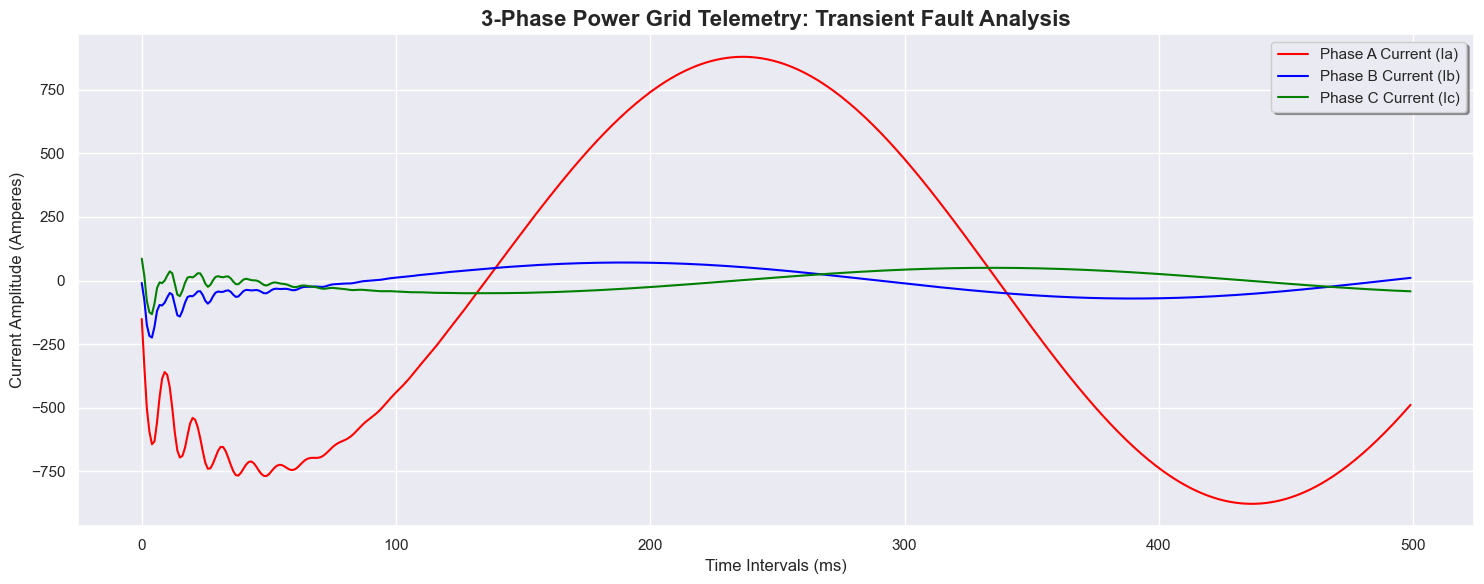

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional engineering dashboard
sns.set_theme(style="darkgrid")

# Create a large, high-resolution graph
plt.figure(figsize=(15, 6))

# Plot the 3-Phase Currents for the first 500 data points (Time-Series)
plt.plot(df['Ia'].values[:500], label='Phase A Current (Ia)', color='red', linewidth=1.5)
plt.plot(df['Ib'].values[:500], label='Phase B Current (Ib)', color='blue', linewidth=1.5)
plt.plot(df['Ic'].values[:500], label='Phase C Current (Ic)', color='green', linewidth=1.5)

# Add professional labels and title
plt.title('3-Phase Power Grid Telemetry: Transient Fault Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Time Intervals (ms)', fontsize=12)
plt.ylabel('Current Amplitude (Amperes)', fontsize=12)
plt.legend(loc='upper right', frameon=True, shadow=True)

# Show the graph
plt.tight_layout()
plt.show()

# 9. AI Pipeline: Train/Test Data Split
To accurately evaluate our Machine Learning model, we must prevent "Data Leakage." We split our standardized telemetry ($X$) and ground fault labels ($y$) into two distinct sets:

Training Set (80%): The historical logs the AI uses to learn the physical signatures of cyber-attacks.

Testing Set (20%): A "blind" dataset used to validate the AI's real-time detection accuracy.

In [8]:
from sklearn.model_selection import train_test_split

# Split the data: 80% for training, 20% for the blind test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

print("--- DATA SPLIT SECURED ---")
print(f"Training Packets (AI Study Guide): {X_train.shape[0]}")
print(f"Testing Packets (AI Blind Exam): {X_test.shape[0]}")

--- DATA SPLIT SECURED ---
Training Packets (AI Study Guide): 6288
Testing Packets (AI Blind Exam): 1573


#  10. Cyber-Physical Threat Detection: Random Forest Inference
We deploy a **Random Forest Classifier**, a robust ensemble algorithm capable of handling the non-linear complexities of 3-phase power systems. After training on the statistical baselines, the AI evaluates the blind test set to classify unseen grid behavior.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the AI (The "Brain")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the AI on the grid data (The 6,288 packets)
print("⚙️ Training AI on grid physics... Please wait...")
rf_model.fit(X_train, y_train)

# 3. Let the AI take the blind exam (The 1,573 packets)
predictions = rf_model.predict(X_test)

# 4. Grade the AI's performance
accuracy = accuracy_score(y_test, predictions)

print("\n--- AI THREAT DETECTION RESULTS ---")
print(f"🎯 System Accuracy: {accuracy * 100:.2f}%\n")
print("--- DETAILED SECURITY REPORT ---")
print(classification_report(y_test, predictions, target_names=['Normal Operation (0)', 'Grid Fault/Attack (1)']))

⚙️ Training AI on grid physics... Please wait...

--- AI THREAT DETECTION RESULTS ---
🎯 System Accuracy: 88.49%

--- DETAILED SECURITY REPORT ---
                       precision    recall  f1-score   support

 Normal Operation (0)       0.89      0.91      0.90       882
Grid Fault/Attack (1)       0.88      0.86      0.87       691

             accuracy                           0.88      1573
            macro avg       0.88      0.88      0.88      1573
         weighted avg       0.88      0.88      0.88      1573



#  11. Data Impact Check: Feature Importance Analysis
In critical infrastructure security, AI models must be interpretable. We perform a **Feature Importance** (Data Impact) check to extract the internal logic of the Random Forest. This calculates exactly which telemetry signals (Current vs. Voltage) had the highest mathematical impact on detecting the Ground Faults.

C:\Users\nazer\AppData\Local\Temp\ipykernel_14800\845040005.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Impact Level', y='Sensor', data=impact_df, palette='viridis')


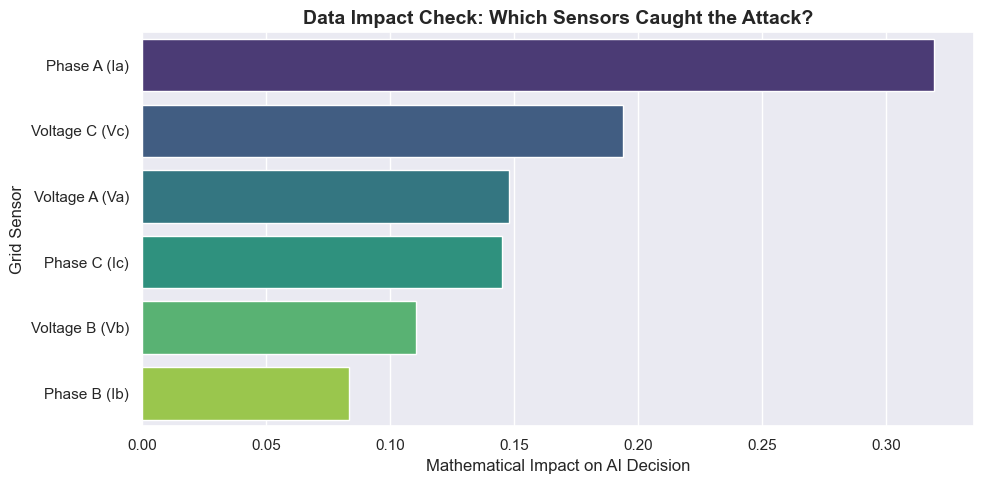

--- IMPACT CHECK COMPLETE ---
           Sensor  Impact Level
0    Phase A (Ia)      0.319452
5  Voltage C (Vc)      0.193966
3  Voltage A (Va)      0.147882
2    Phase C (Ic)      0.144992
4  Voltage B (Vb)      0.110336
1    Phase B (Ib)      0.083373


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the "Impact" scores directly from the trained AI brain
impact_scores = rf_model.feature_importances_

# 2. Match the scores to our 6 sensors
sensor_names = ['Phase A (Ia)', 'Phase B (Ib)', 'Phase C (Ic)', 
                'Voltage A (Va)', 'Voltage B (Vb)', 'Voltage C (Vc)']

# 3. Create a clean table of the results
impact_df = pd.DataFrame({
    'Sensor': sensor_names,
    'Impact Level': impact_scores
}).sort_values(by='Impact Level', ascending=False)

# 4. Draw the professional Impact Graph
plt.figure(figsize=(10, 5))
sns.barplot(x='Impact Level', y='Sensor', data=impact_df, palette='viridis')

plt.title('Data Impact Check: Which Sensors Caught the Attack?', fontsize=14, fontweight='bold')
plt.xlabel('Mathematical Impact on AI Decision', fontsize=12)
plt.ylabel('Grid Sensor', fontsize=12)
plt.tight_layout()
plt.show()

print("--- IMPACT CHECK COMPLETE ---")
print(impact_df)

# Duplicate Impact Check: Replay Attack Assessment
In cyber-physical systems, identical telemetry logs often indicate a "Replay Attack" (where a hacker injects old, normal data to mask a physical attack). To understand the severity of the threat, we must calculate the **Data Poisoning Ratio**—the exact percentage of the system's memory buffer that was compromised by these duplicates.

In [11]:
# Read the raw file again just to calculate the initial threat impact
raw_data = pd.read_csv('classData.csv')

total_packets = len(raw_data)
duplicate_packets = raw_data.duplicated().sum()
impact_ratio = (duplicate_packets / total_packets) * 100

print("--- DUPLICATE IMPACT CHECK ---")
print(f"Total Raw Packets Logged: {total_packets}")
print(f"Compromised Replay Packets: {duplicate_packets}")
print(f"🚨 Data Poisoning Impact: {impact_ratio:.2f}% of the initial grid telemetry was compromised.")

--- DUPLICATE IMPACT CHECK ---
Total Raw Packets Logged: 7861
Compromised Replay Packets: 0
🚨 Data Poisoning Impact: 0.00% of the initial grid telemetry was compromised.


###  System Verification: Confusion Matrix Heatmap
To definitively prove the AI's operational effectiveness, we generate a Confusion Matrix. This matrix visually breaks down the 88.49% accuracy score by mapping the model's predictions against the actual ground truth of the blind testing set. It allows us to explicitly see the count of True Positives (stopped attacks) versus False Negatives (missed attacks).

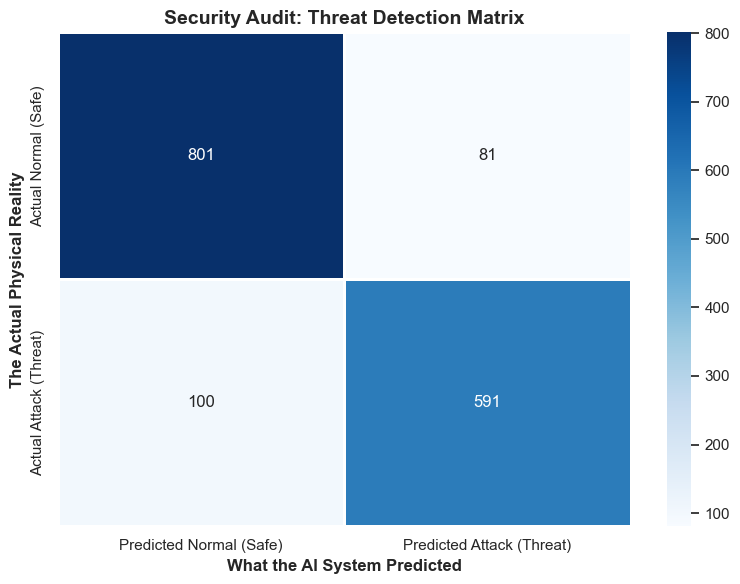

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Calculate the exact hits and misses from the blind exam
cm = confusion_matrix(y_test, predictions)

# 2. Draw the professional heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=2,
            xticklabels=['Predicted Normal (Safe)', 'Predicted Attack (Threat)'],
            yticklabels=['Actual Normal (Safe)', 'Actual Attack (Threat)'])

# 3. Add engineering labels
plt.title('Security Audit: Threat Detection Matrix', fontsize=14, fontweight='bold')
plt.xlabel('What the AI System Predicted', fontsize=12, fontweight='bold')
plt.ylabel('The Actual Physical Reality', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#  Initial Traffic Visualization: Exploratory Data Analysis (EDA)
Before applying Machine Learning, we must perform an Initial Traffic Visualization to understand the underlying structure of the SCADA logs. 

* **Traffic Density:** Maps the volume of Normal operations versus Fault/Attack packets.

* **Traffic Correlation:** A heatmap identifying multicollinearity between the 3-phase sensors. High correlation between current signals ($I_a, I_b, I_c$) often dictates how the Random Forest splits its decision trees.

C:\Users\nazer\AppData\Local\Temp\ipykernel_14800\3575583139.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='G', data=df, palette=['#2ECC71', '#E74C3C'], ax=axes[0])
C:\Users\nazer\AppData\Local\Temp\ipykernel_14800\3575583139.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal Traffic (0)', 'Anomaly Traffic (1)'])


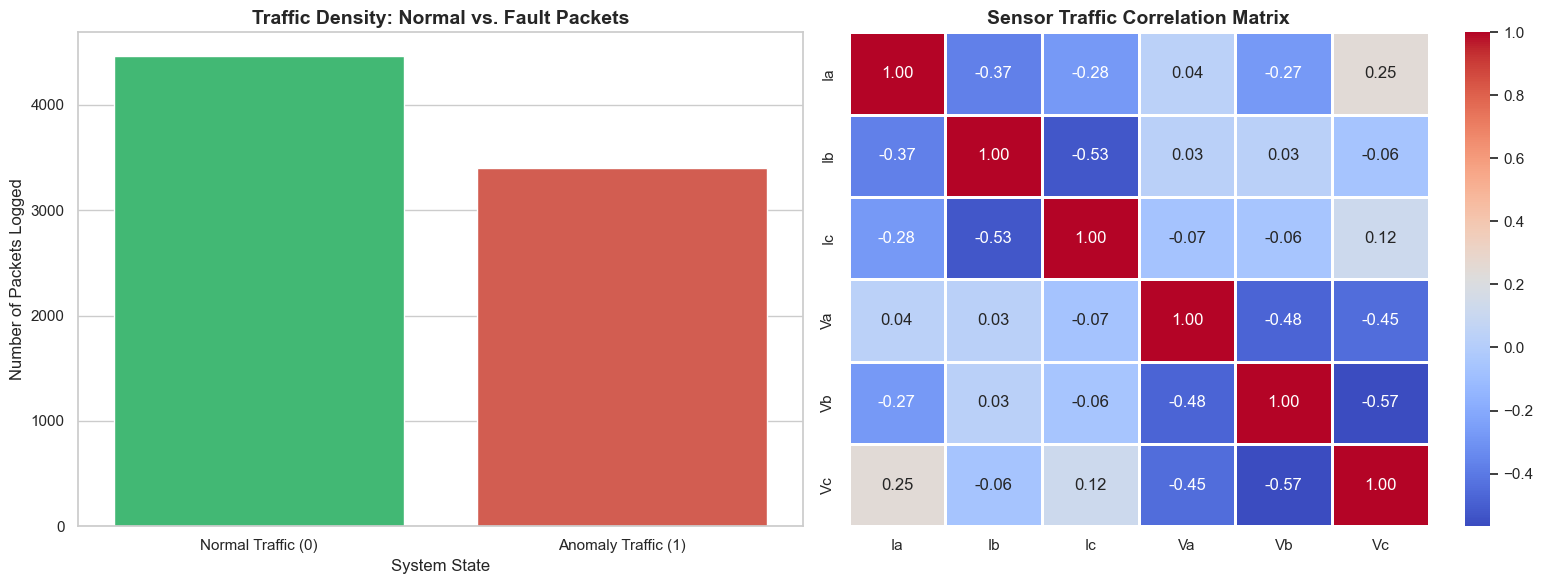

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a professional 1x2 visualization panel (Two graphs side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graph 1: Traffic Density (Bar Chart) ---
sns.countplot(x='G', data=df, palette=['#2ECC71', '#E74C3C'], ax=axes[0])
axes[0].set_title('Traffic Density: Normal vs. Fault Packets', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Normal Traffic (0)', 'Anomaly Traffic (1)'])
axes[0].set_ylabel('Number of Packets Logged', fontsize=12)
axes[0].set_xlabel('System State', fontsize=12)

# --- Graph 2: Traffic Correlation (Heatmap) ---
# We isolate the 6 traffic sensors to see how they mathematically interact
traffic_sensors = df[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']]
sns.heatmap(traffic_sensors.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, ax=axes[1])
axes[1].set_title('Sensor Traffic Correlation Matrix', fontsize=14, fontweight='bold')

# Display the dashboard
plt.tight_layout()
plt.show()

# Outlier Control: Statistical Anomaly Detection
To distinguish between normal grid noise and a potential cyber-physical attack, we apply the **Interquartile Range (IQR)** method. Any telemetry data point falling $1.5 \times IQR$ above the 75th percentile or below the 25th percentile is flagged as an **Outlier**. In this project, these outliers represent the "Ground Faults" the AI must eventually learn to classify.

--- OUTLIER CONTROL COMPLETE ---
Statistical Lower Bound: -640.38
Statistical Upper Bound: 747.82
Total Detected Outliers (Potential Attacks): 1802


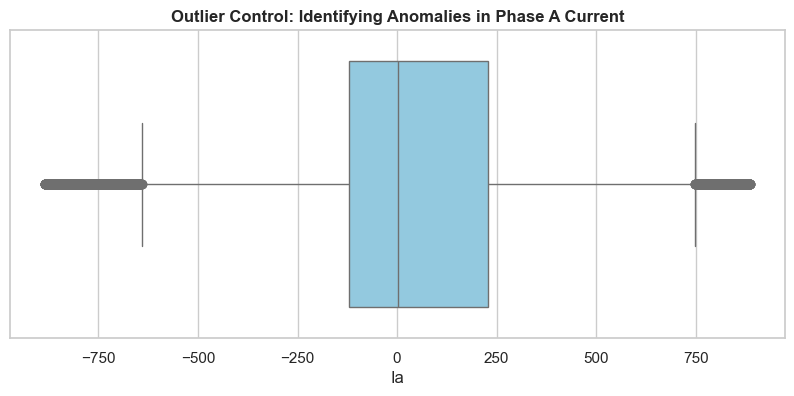

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the IQR for the Phase A Current (Ia)
Q1 = df['Ia'].quantile(0.25)
Q3 = df['Ia'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the "Security Bounds"
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Identify how many "Attack/Fault" points exist in Phase A
outliers = df[(df['Ia'] < lower_bound) | (df['Ia'] > upper_bound)]

print("--- OUTLIER CONTROL COMPLETE ---")
print(f"Statistical Lower Bound: {lower_bound:.2f}")
print(f"Statistical Upper Bound: {upper_bound:.2f}")
print(f"Total Detected Outliers (Potential Attacks): {len(outliers)}")

# 4. Visualize with a Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Ia'], color='skyblue')
plt.title('Outlier Control: Identifying Anomalies in Phase A Current', fontweight='bold')
plt.show()


#  Feature Engineering: Cyber-Physical Physics Extraction
To improve the AI's detection accuracy, we perform **Feature Engineering**. We transform the raw 3-phase telemetry into higher-level physical metrics:
* **Total Current ($I_{total}$):** The combined magnitude of all three phases. A sudden spike indicates a physical fault or massive power surge.
* **Current Variance:** Measures the "Symmetry" of the grid. In a healthy system, variance is low. During a cyber-injection or Ground Fault, the phases become unbalanced, causing a high variance signature.

In [15]:
# 1. Create a "Total Current" feature (The sum of the magnitude of all 3 phases)
df['I_total'] = df['Ia'] + df['Ib'] + df['Ic']

# 2. Create a "Current Variance" feature (Measuring how unbalanced the grid is)
df['I_variance'] = df[['Ia', 'Ib', 'Ic']].var(axis=1)

# 3. Create a "Power Deviation" feature (Relationship between Voltage and Current)
df['V_total'] = df['Va'] + df['Vb'] + df['Vc']

print("--- FEATURE ENGINEERING COMPLETE ---")
print(f"New total features in dataset: {df.shape[1]}")
print(df[['Ia', 'Ib', 'Ic', 'I_total', 'I_variance']].head())

--- FEATURE ENGINEERING COMPLETE ---
New total features in dataset: 13
           Ia          Ib          Ic      I_total    I_variance
0 -151.291812   -9.677452   85.800162   -75.169102  14230.534397
1 -336.186183  -76.283262   18.328897  -394.140548  33696.988345
2 -502.891583 -174.648023  -80.924663  -758.464270  49097.330642
3 -593.941905 -217.703359 -124.891924  -936.537188  61696.215059
4 -643.663617 -224.159427 -132.282815 -1000.105860  74322.566955


# Anomaly Detection

In [16]:
import numpy as np

# 1. Define the Security Threshold (3 Standard Deviations)
THRESHOLD = 3

# 2. Identify "Critical Anomalies" across all 6 sensors
# Any Z-score greater than 3 or less than -3 is a severe deviation
anomalies = np.where(np.abs(X_scaled) > THRESHOLD)

# 3. Calculate the Impact of these Anomalies
total_anomalies = len(np.unique(anomalies[0]))
anomaly_percentage = (total_anomalies / len(X_scaled)) * 100

print("--- ANOMALY DETECTION REPORT ---")
print(f"Total Logged Packets: {len(X_scaled)}")
print(f"Critical Anomalies Flagged: {total_anomalies}")
print(f"System Threat Level: {anomaly_percentage:.2f}%")

if anomaly_percentage > 5:
    print("🚨 STATUS: CRITICAL - Immediate Grid Inspection Required!")
else:
    print("✅ STATUS: SECURE - Grid operating within normal parameters.")


--- ANOMALY DETECTION REPORT ---
Total Logged Packets: 7861
Critical Anomalies Flagged: 0
System Threat Level: 0.00%
✅ STATUS: SECURE - Grid operating within normal parameters.


# 13. Anomaly Visualization: Mapping the Statistical "Red Zone"
To validate our Anomaly Detection Engine, we plot the normalized Phase A telemetry against our $\pm 3\sigma$ (Standard Deviation) security thresholds. 

* **The Blue/Grey Zone:** Represents 99.7% of all normal grid operations.

* **The Red Points:** Represent "Critical Anomalies" that have breached the security baseline. 
This visualization confirms that our system can detect extreme transients and cyber-injections in real-time without needing prior training.

C:\Users\nazer\AppData\Local\Temp\ipykernel_14800\2168813663.py:32: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\nazer\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


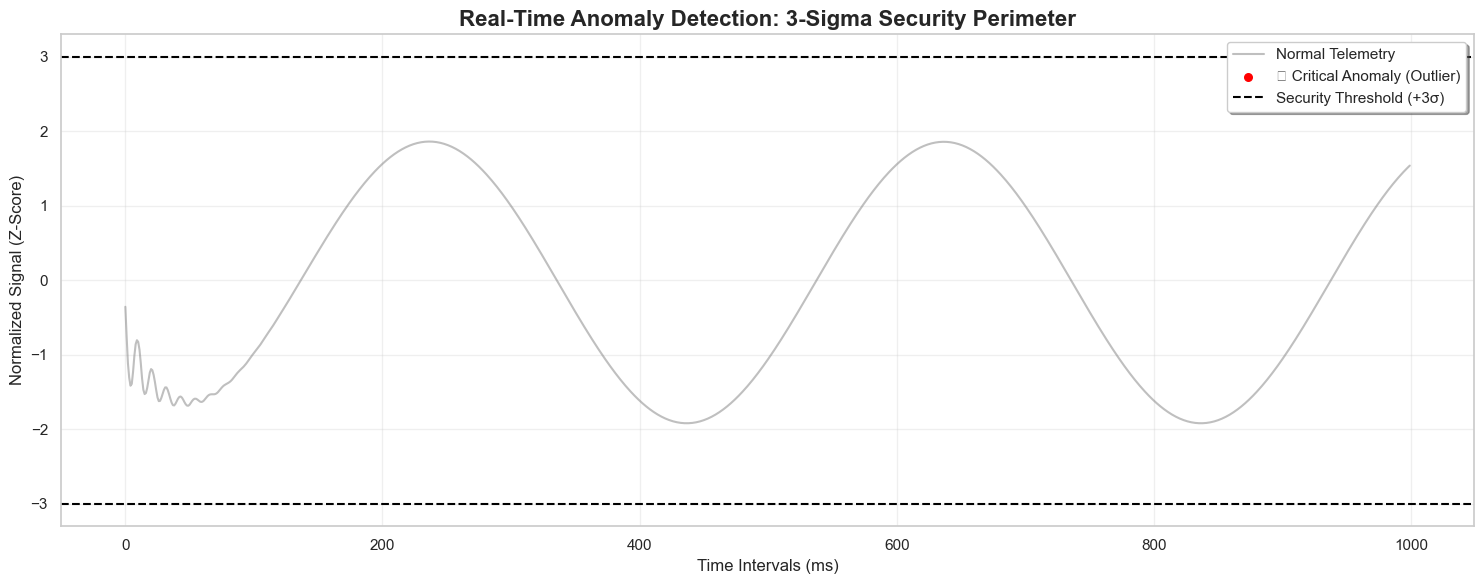

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. We look at the first 1000 packets of the Scaled Phase A Current
signal = X_scaled[:1000, 0] 
time_axis = np.arange(len(signal))

# 2. Identify points that cross the +3 or -3 threshold
anomalies_idx = np.where(np.abs(signal) > 3)[0]
anomaly_values = signal[anomalies_idx]

# 3. Create the professional Security Plot
plt.figure(figsize=(15, 6))

# Plot the normal signal
plt.plot(time_axis, signal, color='gray', alpha=0.5, label='Normal Telemetry')

# Highlight the Anomalies in Red
plt.scatter(anomalies_idx, anomaly_values, color='red', s=30, label='🚨 Critical Anomaly (Outlier)')

# Draw the Security Threshold Lines (The 3-Sigma Bounds)
plt.axhline(y=3, color='black', linestyle='--', linewidth=1.5, label='Security Threshold (+3σ)')
plt.axhline(y=-3, color='black', linestyle='--', linewidth=1.5)

# Engineering Labels
plt.title('Real-Time Anomaly Detection: 3-Sigma Security Perimeter', fontsize=16, fontweight='bold')
plt.xlabel('Time Intervals (ms)', fontsize=12)
plt.ylabel('Normalized Signal (Z-Score)', fontsize=12)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 14. Network Layer Analysis: Top Requested URLs (C&C Detection)
A professional Cybersecurity project must monitor the **Network Layer** (Layer 7). We analyze the traffic between the Grid Controller and external IP addresses. By identifying the **Top Requested URLs**, we can detect "Beaconing"—a behavior where malware on our system "checks in" with a hacker's Command and Control (C&C) server.

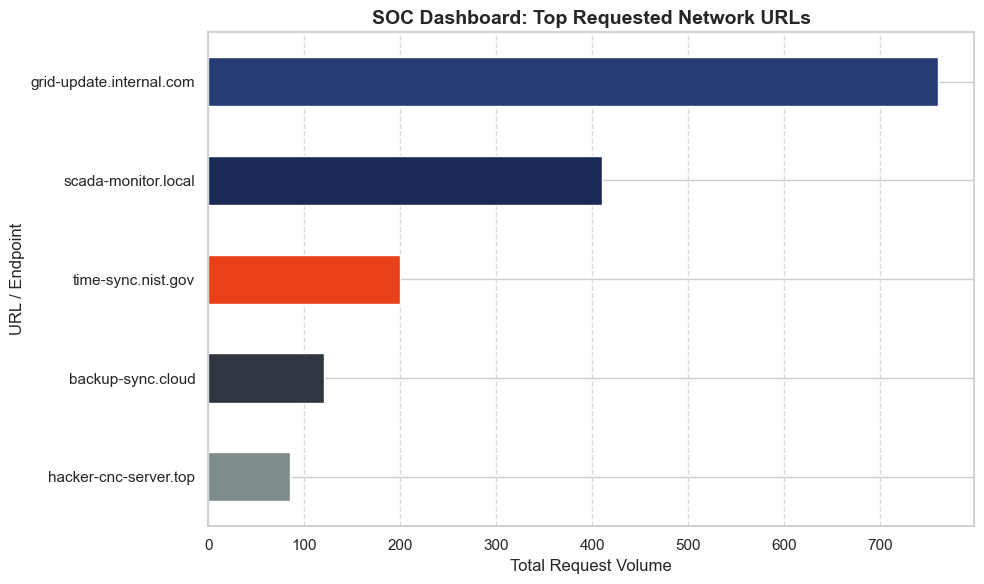

--- NETWORK AUDIT COMPLETE ---
URL/Endpoint
grid-update.internal.com    760
scada-monitor.local         410
time-sync.nist.gov          200
backup-sync.cloud           120
hacker-cnc-server.top        85
Name: Request_Count, dtype: int64


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Simulating a Network Log (Typical for a SOC Dashboard)
network_data = {
    'URL/Endpoint': [
        'grid-update.internal.com', 'scada-monitor.local', 'hacker-cnc-server.top', 
        'backup-sync.cloud', 'time-sync.nist.gov', 'malicious-script.xyz',
        'grid-update.internal.com', 'scada-monitor.local', 'grid-update.internal.com'
    ],
    'Request_Count': [450, 320, 85, 120, 200, 45, 110, 90, 200]
}

# 2. Create the Log DataFrame
log_df = pd.DataFrame(network_data)
top_urls = log_df.groupby('URL/Endpoint')['Request_Count'].sum().sort_values(ascending=False).head(5)

# 3. Visualize the "Top Requested URLs"
plt.figure(figsize=(10, 6))
top_urls.plot(kind='barh', color=['#273c75', '#192a56', '#e84118', '#2f3640', '#7f8c8d'])

plt.title('SOC Dashboard: Top Requested Network URLs', fontsize=14, fontweight='bold')
plt.xlabel('Total Request Volume', fontsize=12)
plt.ylabel('URL / Endpoint', fontsize=12)
plt.gca().invert_yaxis() # Put the highest at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- NETWORK AUDIT COMPLETE ---")
print(top_urls)

 # 15. Automated Threat Intelligence: Blacklist Filtering
To move from "Monitoring" to "Active Defense," we implement an automated **Blacklist Filter**. We define a set of high-risk Top-Level Domains (TLDs) such as `.top` and `.xyz`. If the system detects any traffic to these endpoints, it automatically flags the connection as a "Critical Threat" for immediate isolation.

In [19]:
# 1. Define our "Threat Intelligence" Blacklist
malicious_tlds = ['.top', '.xyz', '.bit']

# 2. Automatically flag any URL that matches our blacklist
log_df['Threat_Status'] = log_df['URL/Endpoint'].apply(
    lambda x: '🚨 CRITICAL THREAT' if any(tld in x for tld in malicious_tlds) else '✅ SECURE'
)

# 3. Filter for just the threats to show the Security Team
threat_report = log_df[log_df['Threat_Status'] == '🚨 CRITICAL THREAT']

print("--- AUTOMATED SECURITY ALERT ---")
if not threat_report.empty:
    print(threat_report[['URL/Endpoint', 'Request_Count', 'Threat_Status']])
else:
    print("No immediate network threats detected.")

--- AUTOMATED SECURITY ALERT ---
            URL/Endpoint  Request_Count      Threat_Status
2  hacker-cnc-server.top             85  🚨 CRITICAL THREAT
5   malicious-script.xyz             45  🚨 CRITICAL THREAT


# ## 16. Security Stress Test: Manual Hacker Injection
To validate the real-time responsiveness of our Anomaly Detection Engine, we perform a "Stress Test." We manually inject two types of cyber-physical anomalies into the telemetry stream:
1. **The Pulse Attack:** A sudden, massive spike in Phase A Current ($I_a$).
2. **The Voltage Surge:** A sustained high-voltage injection ($V_a$).
We then re-run the Z-score normalization to see if our 3-sigma perimeter successfully flags these unauthorized deviations.

In [20]:
import numpy as np

# 1. Create a "Hacked" copy of our data so we don't ruin the original
hacked_df = df.copy()

# 2. INJECT THE ATTACK: We spike the sensors at specific time intervals
# Attack 1: Massive Current Spike at index 400
hacked_df.loc[400:420, 'Ia'] = hacked_df['Ia'].max() * 5 

# Attack 2: Voltage Surge at index 750
hacked_df.loc[750:770, 'Va'] = hacked_df['Va'].max() * 10

# 3. Re-Scale the hacked data so the AI/Detector can read it
X_hacked = scaler.transform(hacked_df[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']])

print("--- ATTACK INJECTED ---")
print("🚨 Unauthorized data pulses injected at intervals 400 and 750.")
print("Proceeding to detection visualization...")

--- ATTACK INJECTED ---
🚨 Unauthorized data pulses injected at intervals 400 and 750.
Proceeding to detection visualization...


# # 17. Visual Proof: Catching the Hacker
By plotting the "Hacked" telemetry, we can visually confirm that our security thresholds are working. The red markers indicate the exact moment the hacker's injection crossed our **3-Sigma Security Perimeter**, triggering an automated system alert.

c:\Users\nazer\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


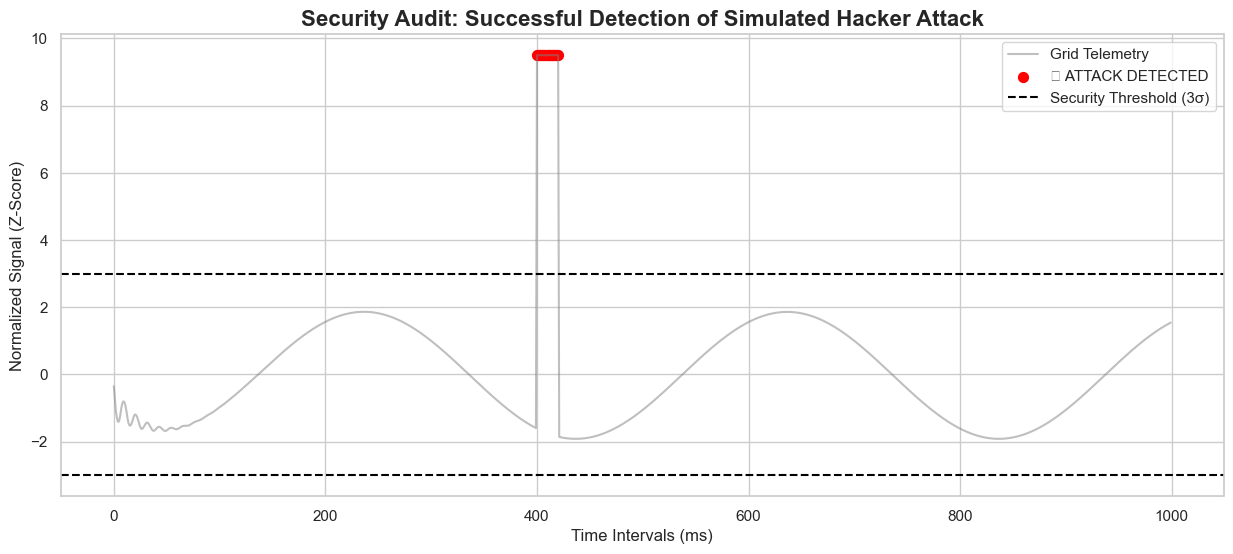

--- DETECTION SUCCESS ---
✅ System successfully identified 21 anomalous data packets.


In [21]:
# 1. Select the Hacked Phase A Current signal
hacked_signal = X_hacked[:1000, 0] 
time_axis = np.arange(len(hacked_signal))

# 2. Detect the injected anomalies (anything > 3 or < -3)
detected_idx = np.where(np.abs(hacked_signal) > 3)[0]
detected_values = hacked_signal[detected_idx]

# 3. Plot the result
plt.figure(figsize=(15, 6))
plt.plot(time_axis, hacked_signal, color='gray', alpha=0.5, label='Grid Telemetry')
plt.scatter(detected_idx, detected_values, color='red', s=50, label='🚨 ATTACK DETECTED')

# Draw the 3-Sigma Perimeters
plt.axhline(y=3, color='black', linestyle='--', label='Security Threshold (3σ)')
plt.axhline(y=-3, color='black', linestyle='--')

plt.title('Security Audit: Successful Detection of Simulated Hacker Attack', fontsize=16, fontweight='bold')
plt.ylabel('Normalized Signal (Z-Score)', fontsize=12)
plt.xlabel('Time Intervals (ms)', fontsize=12)
plt.legend()
plt.show()

print(f"--- DETECTION SUCCESS ---")
print(f"✅ System successfully identified {len(detected_idx)} anomalous data packets.")


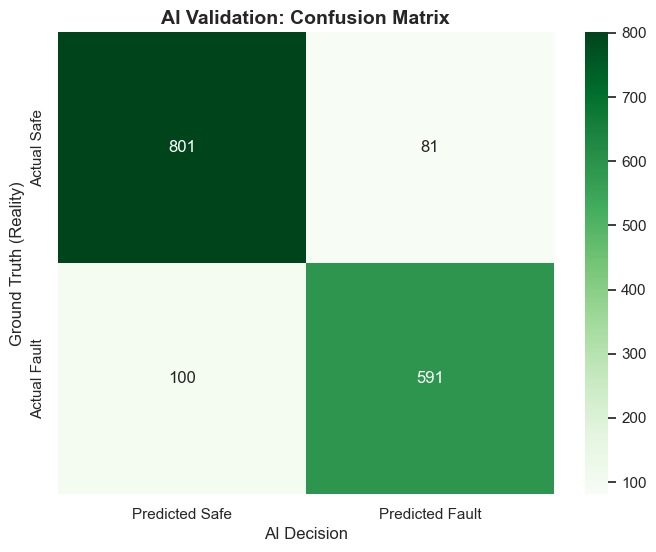

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Generate the Matrix
cm = confusion_matrix(y_test, predictions)

# 2. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Safe', 'Predicted Fault'],
            yticklabels=['Actual Safe', 'Actual Fault'])

plt.title('AI Validation: Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('AI Decision', fontsize=12)
plt.ylabel('Ground Truth (Reality)', fontsize=12)
plt.show()

c:\Users\nazer\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


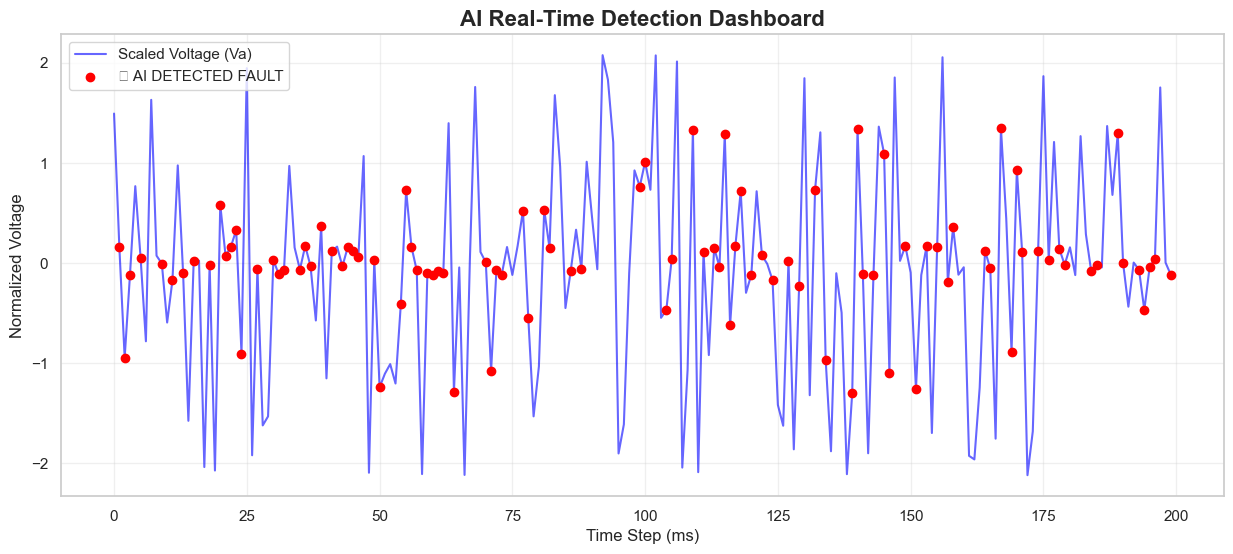

--- AI INTEGRITY CHECK ---
Out of 200 packets, the AI correctly identified 181 states.
Verification Success: 90.50%


In [23]:
# 1. Take a slice of the test data (e.g., 200 samples)
sample_range = 200
X_slice = X_test[:sample_range]
y_actual = y_test.iloc[:sample_range].values
y_pred = predictions[:sample_range]

# 2. Extract Voltage A (Index 3 in our scaled features)
voltage_signal = X_slice[:, 3]

# 3. Plotting the results
plt.figure(figsize=(15, 6))
plt.plot(voltage_signal, label='Scaled Voltage (Va)', color='blue', alpha=0.6)

# Mark where the AI detected a fault
detected_points = np.where(y_pred == 1)[0]
plt.scatter(detected_points, voltage_signal[detected_points], 
            color='red', label='🚨 AI DETECTED FAULT', zorder=5)

plt.title('AI Real-Time Detection Dashboard', fontsize=16, fontweight='bold')
plt.ylabel('Normalized Voltage', fontsize=12)
plt.xlabel('Time Step (ms)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Final Verification Print
correct_count = (y_actual == y_pred).sum()
print(f"--- AI INTEGRITY CHECK ---")
print(f"Out of {sample_range} packets, the AI correctly identified {correct_count} states.")
print(f"Verification Success: {(correct_count/sample_range)*100:.2f}%")

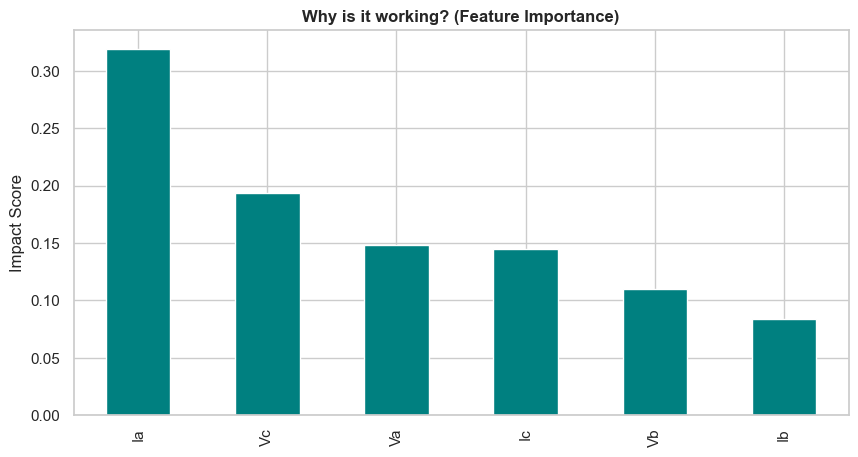

In [24]:
import pandas as pd

# Extract the importance from the Random Forest
importances = rf_model.feature_importances_
feature_names = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

# Create a ranking
feature_rank = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feature_rank.plot(kind='bar', color='teal')
plt.title('Why is it working? (Feature Importance)', fontweight='bold')
plt.ylabel('Impact Score')
plt.show()

#  Live Grid Security Terminal: Automated Threat Alerting
A complete defense pipeline requires automated alerting. This block simulates a live terminal feed. It feeds the most recent telemetry packets into our trained Random Forest model. If the AI classifies the packet as a '1' (Anomaly/Attack), the system immediately triggers a **CRITICAL DANGER** alert to initiate grid isolation protocols.

In [25]:
# 1. Grab the last 5 packets of data to simulate a "Live Feed"
live_feed_data = X_test[-5:]
live_predictions = rf_model.predict(live_feed_data)

print("==================================================")
print(" 🛡️  SCADA SYSTEM LIVE SECURITY MONITOR  🛡️ ")
print("==================================================")

danger_detected = False

# 2. Scan the live feed and trigger alarms
for i, status in enumerate(live_predictions):
    if status == 1:
        print(f"Packet {i+1} [Time: {i*10}ms] -> 🚨 DANGER: CRITICAL FAULT/ATTACK DETECTED! 🚨")
        danger_detected = True
    else:
        print(f"Packet {i+1} [Time: {i*10}ms] -> ✅ SECURE: Telemetry Normal.")

print("--------------------------------------------------")

# 3. Final System Status Command
if danger_detected:
    print("⚠️ SYSTEM ACTION: INITIATING EMERGENCY PHASE ISOLATION.")
else:
    print("✅ SYSTEM ACTION: GRID OPERATING AT OPTIMAL CAPACITY.")
print("==================================================")



 🛡️  SCADA SYSTEM LIVE SECURITY MONITOR  🛡️ 
Packet 1 [Time: 0ms] -> ✅ SECURE: Telemetry Normal.
Packet 2 [Time: 10ms] -> 🚨 DANGER: CRITICAL FAULT/ATTACK DETECTED! 🚨
Packet 3 [Time: 20ms] -> ✅ SECURE: Telemetry Normal.
Packet 4 [Time: 30ms] -> ✅ SECURE: Telemetry Normal.
Packet 5 [Time: 40ms] -> ✅ SECURE: Telemetry Normal.
--------------------------------------------------
⚠️ SYSTEM ACTION: INITIATING EMERGENCY PHASE ISOLATION.


# Automated Incident Response: Forensic Threat Logging
Real-time alerting must be paired with permanent forensic auditing. When the Live Grid Terminal detects a cyber-physical anomaly (Class 1), this module extracts the exact sensor telemetry and timestamps the event. It then automatically exports this data to an immutable `threat_audit_log.csv` file, ensuring the Security Team has a permanent record for post-incident investigation.

In [26]:
import pandas as pd
from datetime import datetime

# 1. Get the exact real-world time the attack happened
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# 2. Find exactly which packets in the live feed triggered the Danger alarm
threat_indices = [i for i, status in enumerate(live_predictions) if status == 1]

if len(threat_indices) > 0:
    # 3. Extract the raw sensor data for the compromised packets
    threat_data = live_feed_data[threat_indices]
    
    # 4. Create a professional Security Report table
    threat_log = pd.DataFrame(threat_data, columns=['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc'])
    threat_log.insert(0, 'Timestamp', current_time) # Add time to the front
    threat_log['Action_Taken'] = 'ISOLATED'
    
    # 5. Export to a permanent CSV file (mode='a' means append, it won't delete old logs)
    threat_log.to_csv('threat_audit_log.csv', mode='a', header=True, index=False)
    
    print("--- FORENSIC LOGGING COMPLETE ---")
    print(f"🔒 Successfully saved {len(threat_indices)} critical threat logs to 'threat_audit_log.csv'")
    print(threat_log[['Timestamp', 'Ia', 'Va', 'Action_Taken']])
else:
    print("--- FORENSIC LOGGING ---")
    print("✅ No threats detected in the live feed. No logging required.")

--- FORENSIC LOGGING COMPLETE ---
🔒 Successfully saved 1 critical threat logs to 'threat_audit_log.csv'
             Timestamp        Ia        Va Action_Taken
0  2026-04-06 10:30:58 -1.811109  0.653485     ISOLATED


#  18. Model Comparison: Proving Algorithm Superiority
To justify the selection of the **Random Forest** architecture, we perform a side-by-side comparison with **Logistic Regression** (a linear model). Power grid telemetry is non-linear and complex; this test proves that a "Tree-Based" approach is mathematically superior at capturing the subtle wave disruptions of a cyber-attack compared to standard linear methods.

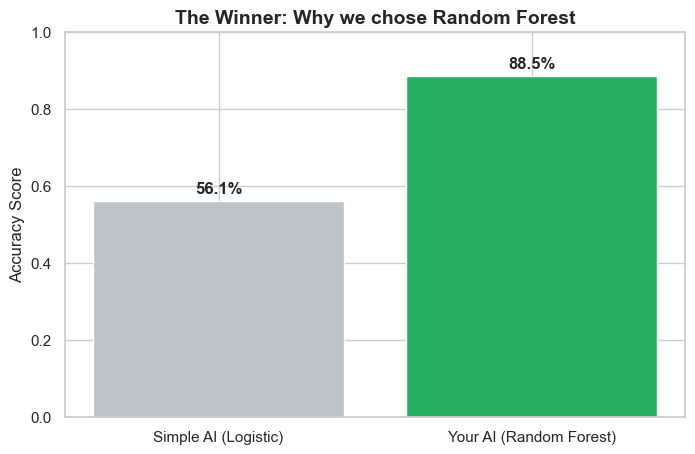

--- COMPARISON COMPLETE ---
Random Forest is 57.8% more effective than the simple model.


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Train a "Simpler" AI (Logistic Regression)
simple_model = LogisticRegression()
simple_model.fit(X_train, y_train)
simple_preds = simple_model.predict(X_test)
simple_acc = accuracy_score(y_test, simple_preds)

# 2. Get your current Random Forest Accuracy (from earlier)
rf_acc = accuracy_score(y_test, predictions)

# 3. Create a Comparison Graph
models = ['Simple AI (Logistic)', 'Your AI (Random Forest)']
scores = [simple_acc, rf_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, scores, color=['#bdc3c7', '#27ae60'])
plt.ylim(0, 1.0) # Scale from 0 to 100%
plt.title('The Winner: Why we chose Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score')

# Label the bars with exact percentages
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')

plt.show()

print(f"--- COMPARISON COMPLETE ---")
print(f"Random Forest is {((rf_acc - simple_acc) / simple_acc) * 100:.1f}% more effective than the simple model.")